# Data drift detection

In the context of forecasting and machine learning, **data drift** refers to a change in the statistical properties of the input data over time compared to the data on which the model was originally trained. When this happens, the model may start to produce less accurate or unreliable predictions, since it no longer generalizes well to the new data distribution.

Data drift can take several forms:

- **Covariate Drift (Feature Drift)**: The distribution of the input features changes, but the relationship between features and target remains the same. Example: A model was trained when a feature had values in a certain range. Over time, if that feature shifts to a different range, covariate drift occurs.

- **Prior Probability Drift (Label Drift)**: The distribution of the target variable changes. Example: A model trained to predict energy consumption during a season may fail if seasonal patterns change due to external factors.

- **Concept Drift**: The relationship between input features and the target variable changes. Example: A model predicting energy consumption from weather data might fail if new technologies or behaviors alter how weather affects energy usage.

Detecting and addressing data drift is crucial for maintaining model reliability in production environments. Common strategies include:

- **Monitoring input data** during prediction to detect changes early.

- **Tracking model performance** metrics (e.g., accuracy, precision, recall) over time.

- **Retraining models** periodically with recent data to adapt to evolving conditions.

**Skforecast** includes two dedicated classes for data drift detection:

+ [`PopulationDriftDetector`](../api/drift_detection.html#skforecast.drift_detection._population_drift.PopulationDriftDetector): detects changes at the **population level**, helping identify when a forecasting model should be retrained.

+ [`RangeDriftDetector`](../api/drift_detection.html#skforecast.drift_detection._range_drift.RangeDriftDetector): detects changes at the **single-observation level**, suitable for validating input data during the prediction phase.

## Drift detection during model training

The [`PopulationDriftDetector`](../api/drift_detection.html#skforecast.drift_detection._population_drift.PopulationDriftDetector) is designed to detect **feature drift** and **label drift** in time series data. It evaluates whether the distribution of the input variables (both target and exogenous) remains consistent with the data used to train the forecasting model.

By comparing **recent observations** with the **training data**, the detector identifies significant distributional changes that may indicate the model needs retraining.

The statistical metrics used depend on the data type:

- **Numerical features**: Kolmogorov–Smirnov statistic and Jensen–Shannon distance.

- **Categorical features**: Chi-squared statistic and Jensen–Shannon distance.

The API follows the same design principles as Skforecast forecasters:

+ The same data used to train a forecaster can also be used to fit a [`PopulationDriftDetector`](../api/drift_detection.html#skforecast.drift_detection._population_drift.PopulationDriftDetector).

+ When new historical data becomes available (i.e., multiple new observations), the `predict` method can be used to check for drift.

+ If drift is detected, users should analyze its cause and consider retraining or recalibrating the forecasting model.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

<p>

  This implementation is inspired by <a href="https://nannyml.readthedocs.io/en/stable/tutorials/detecting_data_drift/univariate_drift_detection.html" target="_blank" rel="noopener noreferrer">NannyML's DriftDetector</a>, but provides a <b>lightweight adaptation</b> tailored to Skforecast’s time series context.

  <ul>
      <li>
        <b>Memory-efficient:</b> The detector does not store the full reference data. Instead, it keeps only the precomputed statistics required to evaluate drift efficiently during prediction.
      </li>
      <li>
        <b>Empirical thresholds:</b> In addition to standard deviation-based thresholds, thresholds can be derived from a specified quantile of empirical distributions. These distributions are computed from reference data chunks using a leave-one-chunk-out approach to avoid self-comparison bias.
      </li>
      <li>
        <b>Out-of-range detection:</b> It also checks for out-of-range values in numerical features and for unseen categories in categorical features.
      </li>
      <li>
        <b>Multiple time series support:</b> It can handle multiple time series, each one with its own exogenous variables.
      </li>
  </ul>

  If the user requires more advanced features, such as multivariate drift detection or data quality checks, consider using <a href="https://nannyml.readthedocs.io/en/stable/" target="_blank" rel="noopener noreferrer">NannyML</a> directly. 
</p>

</div>


To illustrate how drift detection works, the dataset is divided into a **training set** and a **new data partition**, simulating a real-world scenario where additional data becomes available after the model has been trained.

To emulate data drift, the variable `temp` in the new data partition is intentionally modified:

- **June:** Temperatures are increased by **+10 ºC**.

- **July:** Temperatures are increased by **+20 ºC**.

- **October:** Temperatures are replaced by a **constant value** equal to the mean of the original data. Although this value lies within the original range, its lack of variability makes it statistically atypical.

- **December:** Temperatures are decreased by **-10 ºC**.

The variable `hum` remains unchanged throughout the new data partition, serving as a control variable to demonstrate that the drift detector correctly identifies no drift when none exists.

In [1]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme
from skforecast.drift_detection import PopulationDriftDetector
import numpy as np
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.ensemble import HistGradientBoostingRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.drift_detection import RangeDriftDetector

In [2]:
# Data
# ==============================================================================
data = fetch_dataset('bike_sharing', verbose=False)
data = data[['temp', 'hum']]
display(data.head())
data_train = data.iloc[: 9000].copy()
data_new  = data.iloc[9000:].copy()

,temp,hum
date_time,,
2011-01-01 00:00:00,9.84,81.0
2011-01-01 01:00:00,9.02,80.0
2011-01-01 02:00:00,9.02,80.0
2011-01-01 03:00:00,9.84,75.0
2011-01-01 04:00:00,9.84,75.0


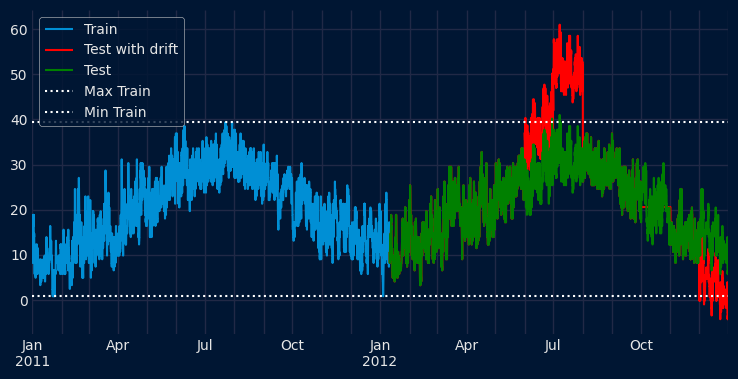

In [3]:
# Inject changes in the distribution
# ==============================================================================
data_new_drift = data_new.copy()

# Add 10 to observations of June 2012
data_new_drift.loc['2012-06-01 00:00:00':'2012-06-30 23:00:00', 'temp'] = (
    data_new_drift.loc['2012-06-01 00:00:00':'2012-06-30 23:00:00', 'temp'] + 10
)

# Add 20 to observations of July 2012
data_new_drift.loc['2012-07-01 00:00:00':'2012-07-31 23:00:00', 'temp'] = (
    data_new_drift.loc['2012-07-01 00:00:00':'2012-07-31 23:00:00', 'temp'] + 20
)

# Constant mean value in October 2012
data_new_drift.loc['2012-10-01 00:00:00':'2012-10-31 23:00:00', 'temp'] = (
    data_new_drift.loc['2012-10-01 00:00:00':'2012-10-31 23:00:00', 'temp'].mean()
)

# Substract 10 from observations of December 2012
data_new_drift.loc['2012-12-01 00:00:00':'2012-12-31 23:00:00', 'temp'] = (
    data_new_drift.loc['2012-12-01 00:00:00':'2012-12-31 23:00:00', 'temp'] - 10
)

# Plot
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(8, 4))
data_train.loc[:, 'temp'].plot(ax=ax, label='Train')
data_new_drift.loc[:, 'temp'].plot(ax=ax, label='Test with drift', color='red')
data_new.loc[:, 'temp'].plot(ax=ax, label='Test', color='green')
ax.axhline(data_train['temp'].max(), color='white', linestyle=':', label='Max Train')
ax.axhline(data_train['temp'].min(), color='white', linestyle=':', label='Min Train')
ax.set_xlabel("")
ax.legend()
plt.show();


When creating a [`PopulationDriftDetector`](../api/drift_detection.html#skforecast.drift_detection._population_drift.PopulationDriftDetector) instance, **four key arguments** control how drift is detected and calibrated:

+ `chunk_size`: Defines how the data is partitioned into chunks for distribution comparison. A smaller chunk size enables more frequent drift checks but increases statistical variability, which may lead to false positives. Larger chunk sizes reduce variability and produce more stable estimates, at the cost of slower drift detection. The optimal value depends on the desired balance between sensitivity and stability, as well as the volume and temporal structure of the data.

+ `threshold`: Specifies the threshold used to determine whether drift has occurred. The higher the threshold, the more conservative the detector will be in flagging drift. Its interpretation depends on the selected `threshold_method`.

+ `threshold_method`: Strategy used to estimate drift thresholds from empirical distributions computed on the reference data. Available options are:
        
  - `'std'`: Thresholds are estimated as a function of the mean and standard deviation of the empirical distribution (`mean + threshold * std`). This approach is computationally efficient, as it does not rely on leave-one-chunk-out procedures.

  - `'quantile'`: Thresholds are derived from a specified quantile of the empirical distribution using leave-one-chunk-out cross-validation to avoid self-comparison bias. This is statistically more correct for quantile-based thresholds but computationally more expensive.

+ `max_out_of_range_proportion`: Maximum allowed proportion of observations outside the reference value range for numeric features. If the proportion of out-of-range values in a new data chunk exceeds this threshold, drift is flagged for the corresponding feature. This parameter provides an additional safeguard against distribution shifts that manifest as values falling outside the observed reference range.

In [4]:
# Fit detector using the training data
# ==============================================================================
detector = PopulationDriftDetector(
               chunk_size       = 'MS',  # Monthly chunks         
               threshold        = 3,
               threshold_method = 'std',
               max_out_of_range_proportion = 0.1
           )
detector.fit(data_train)
detector

======================= 
PopulationDriftDetector 
======================= 
Chunk size                  = MS 
Threshold                   = 3 
Threshold method            = std 
Max out of range proportion = 0.1 
Is fitted                   = True 
Fitted features             = ['temp', 'hum'] 
Skforecast version          = 0.24.0

Once the detector has been **fitted**, it can be used to **evaluate new data** using the `predict` method. This method returns two DataFrames:

+ **Detailed results:** Contain information about the computed statistics, thresholds, and drift status for each data chunk.

+ **Summary results:** Provide an overview showing the number and percentage of chunks where drift was detected.

In [5]:
# Detect drift in new data
# ==============================================================================
drift_results, drift_summary = detector.predict(data_new_drift)

In [6]:
# Drift detailed results
# ==============================================================================
drift_results

,chunk,chunk_start,chunk_end,feature,ks_statistic,ks_threshold,chi2_statistic,chi2_threshold,js_statistic,js_threshold,reference_range,prop_out_of_range,max_out_of_range_proportion,is_out_of_range,drift_ks_statistic,drift_chi2_statistic,drift_js,drift_detected
0,0,2012-01-11,2012-01-31 23:00:00,temp,0.490175,0.904773,NaN,NaN,0.546958,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,False,False
1,1,2012-02-01,2012-02-29 23:00:00,temp,0.477663,0.904773,NaN,NaN,0.523748,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,False,False
2,2,2012-03-01,2012-03-31 23:00:00,temp,0.232412,0.904773,NaN,NaN,0.373938,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,False,False
3,3,2012-04-01,2012-04-30 23:00:00,temp,0.217000,0.904773,NaN,NaN,0.455947,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,False,False
4,4,2012-05-01,2012-05-31 23:00:00,temp,0.443082,0.904773,NaN,NaN,0.539446,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,False,False
5,5,2012-06-01,2012-06-30 23:00:00,temp,0.902111,0.904773,NaN,NaN,0.877304,0.806410,"(0.8200000000000001, 39.36)",0.344444,0.1,True,False,False,True,True
6,6,2012-07-01,2012-07-31 23:00:00,temp,1.000000,0.904773,NaN,NaN,1.000000,0.806410,"(0.8200000000000001, 39.36)",1.000000,0.1,True,True,False,True,True
7,7,2012-08-01,2012-08-31 23:00:00,temp,0.637269,0.904773,NaN,NaN,0.652528,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,False,False
8,8,2012-09-01,2012-09-30 23:00:00,temp,0.446389,0.904773,NaN,NaN,0.518331,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,False,False
9,9,2012-10-01,2012-10-31 23:00:00,temp,0.537556,0.904773,NaN,NaN,0.863793,0.806410,"(0.8200000000000001, 39.36)",0.000000,0.1,False,False,False,True,True


In [7]:
# Drift summary
# ==============================================================================
drift_summary

,feature,n_chunks_with_drift,pct_chunks_with_drift,chunks_with_drift
0,hum,0,0.000000,[]
1,temp,4,33.333333,"[5, 6, 9, 11]"


As expected, the detector identifies drift in the modified new data, while no drift is detected in unaltered data.

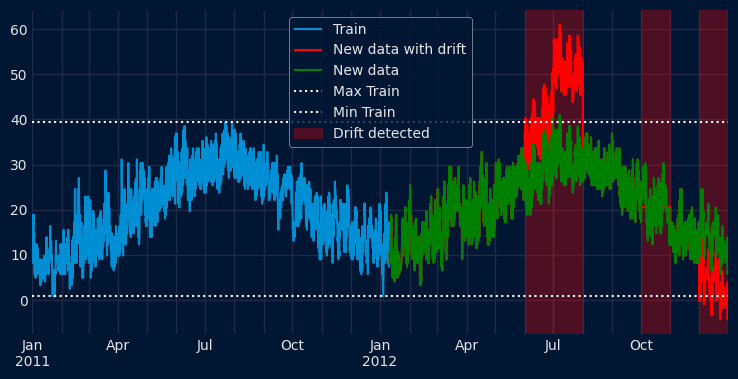

In [8]:
# Highlight chunks with detected drift
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(8, 4))
data_train.loc[:, 'temp'].plot(ax=ax, label='Train')
data_new_drift.loc[:, 'temp'].plot(ax=ax, label='New data with drift', color='red')
data_new.loc[:, 'temp'].plot(ax=ax, label='New data', color='green')
ax.axhline(data_train['temp'].max(), color='white', linestyle=':', label='Max Train')
ax.axhline(data_train['temp'].min(), color='white', linestyle=':', label='Min Train')
for row in drift_results.query('drift_detected == True').itertuples():
    chunk_start = row.chunk_start
    chunk_end = row.chunk_end
    drift_detected = row.drift_detected
    if drift_detected:
        ax.axvspan(chunk_start, chunk_end, color='red', alpha=0.3, label='Drift detected')

# Remove repetitive labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_xlabel("")
plt.show();


`PopulationDriftDetector` can be used with multiple time series simultaneously, each one with its own features. In this case, the input data must be a pandas DataFrame with a MultiIndex, where the first level is the series identifier, and the second level corresponds to the temporal index.

In [9]:
# Multi-series data
# ==============================================================================
data_multiseries = pd.concat(
    [
        data.assign(series='series_1'),
        data.assign(series='series_2'),
        data.assign(series='series_3')
    ]
).set_index('series', append=True).swaplevel(0, 1)
display(data_multiseries)

# Split train/test per series
data_multiseries_train = (
    data_multiseries
    .groupby(level='series', group_keys=False)
    .apply(lambda x: x.iloc[:9000])
)

data_multiseries_new = (
    data_multiseries
    .groupby(level='series', group_keys=False)
    .apply(lambda x: x.iloc[9000:])
)

temp   hum
series   date_time                       
series_1 2011-01-01 00:00:00   9.84  81.0
         2011-01-01 01:00:00   9.02  80.0
         2011-01-01 02:00:00   9.02  80.0
         2011-01-01 03:00:00   9.84  75.0
         2011-01-01 04:00:00   9.84  75.0
...                             ...   ...
series_3 2012-12-31 19:00:00  10.66  60.0
         2012-12-31 20:00:00  10.66  60.0
         2012-12-31 21:00:00  10.66  60.0
         2012-12-31 22:00:00  10.66  56.0
         2012-12-31 23:00:00  10.66  65.0

[52632 rows x 2 columns]

In [10]:
# Multi-series PopulationDriftDetector
# ==============================================================================
detector = PopulationDriftDetector(
               chunk_size       = 'MS',  # Monthly chunks         
               threshold        = 3,
               threshold_method = 'std',
               max_out_of_range_proportion = 0.1
           )
detector.fit(data_multiseries_train)
detector

======================= 
PopulationDriftDetector 
======================= 
Chunk size                  = MS 
Threshold                   = 3 
Threshold method            = std 
Max out of range proportion = 0.1 
Is fitted                   = True 
Fitted features             = {'series_1': ['temp', 'hum'], 'series_2': ['temp', 'hum'], 'series_3': ['temp', 'hum']} 
Skforecast version          = 0.24.0

In [11]:
# Print thresholds per series
# ==============================================================================
detector.get_thresholds()

,series_id,feature,ks_threshold,chi2_threshold,js_threshold,max_out_of_range_proportion
0,series_1,temp,0.904773,NaN,0.806410,0.1
1,series_1,hum,0.385918,NaN,0.423199,0.1
2,series_2,temp,0.904773,NaN,0.806410,0.1
3,series_2,hum,0.385918,NaN,0.423199,0.1
4,series_3,temp,0.904773,NaN,0.806410,0.1
5,series_3,hum,0.385918,NaN,0.423199,0.1


In [12]:
# Detect drift in new multi-series data
# ==============================================================================
drift_results, drift_summary = detector.predict(data_multiseries_new)
drift_summary

,series_id,feature,n_chunks_with_drift,pct_chunks_with_drift,chunks_with_drift
0,series_1,hum,0,0.0,[]
1,series_1,temp,0,0.0,[]
2,series_2,hum,0,0.0,[]
3,series_2,temp,0,0.0,[]
4,series_3,hum,0,0.0,[]
5,series_3,temp,0,0.0,[]


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

<p>
    When calendar features are automatically generated by the forecaster using the <code>calendar_features</code> argument, they are excluded from the drift detection
    process. However, if you manually introduce calendar-related variables as part of the exogenous variables (<code>exog</code>), they <b>will</b> be included in the analysis. This is an important distinction, as the natural progression of time-based variables (like the year) can inadvertently trigger false drift alerts.

  To learn more about this topic, visit <a href="../user_guides/calendar-features.html" target="_blank" rel="noopener noreferrer">Calendar features in Skforecast</a>. 
</p>

</div>


## Drift detection during prediction

Skforecast provides the class [`RangeDriftDetector`](../api/drift_detection.html#skforecast.drift_detection._range_drift.RangeDriftDetector) to detect **covariate drift** in both single and multiple time series, as well as in exogenous variables. 

The detector checks whether the input data (lags and exogenous variables) used to **predict new values** fall within the range of the data used to train the model. 

Its API follows the same design as the forecasters: 

+ The data used to train a forecaster can also be used to fit the [`RangeDriftDetector`](../api/drift_detection.html#skforecast.drift_detection._range_drift.RangeDriftDetector).

+ The data passed to the forecaster's `predict` method can also be passed to the `RangeDriftDetector`'s `predict` method to check for drift in the input data before making predictions. 

+ If drift is detected, users should analyze its cause and consider whether the model is still appropriate for making predictions with the new data.


### Detecting out-of-range values in a single series

The `RangeDriftDetector` checks whether the values of a time series remain consistent with the data seen during training.

+ For **numeric variables**, it verifies that each new value falls **within the minimum and maximum range** of the training data. Values outside this range are flagged as potential drift.

+ For **categorical variables**, it checks whether each new category was **observed during training**. Unseen categories are flagged as potential drift.

This mechanism allows you to quickly identify when the model is receiving inputs that differ from those it was trained on, helping you decide whether to **retrain the model** or **adjust preprocessing**.

In [13]:
# Simulated data
# ==============================================================================
rgn = np.random.default_rng(123)
y_train = pd.Series(
    rgn.normal(loc=10, scale=2, size=100),
    index=pd.date_range(start="2020-01-01", periods=100),
    name="y",
)
exog_train = pd.DataFrame(
    {
        "exog_1": rgn.normal(loc=10, scale=2, size=100),
        "exog_2": rgn.choice(["A", "B", "C", "D", "E"], size=100),
    },
    index=y_train.index,
)

display(y_train.head())
display(exog_train.head())

2020-01-01     8.021757
2020-01-02     9.264427
2020-01-03    12.575851
2020-01-04    10.387949
2020-01-05    11.840462
Freq: D, Name: y, dtype: float64

,exog_1,exog_2
2020-01-01,8.968465,B
2020-01-02,13.316227,B
2020-01-03,9.405475,A
2020-01-04,7.233246,A
2020-01-05,9.437591,A


In [14]:
# Train RangeDriftDetector
# ==============================================================================
detector = RangeDriftDetector()
detector.fit(series=y_train, exog=exog_train)
detector


================== 
RangeDriftDetector 
================== 
Fitted series          = y 
Series value ranges    = {'y': (5.5850578036003915, 14.579819894629157)} 
Fitted exogenous       = exog_1, exog_2 
Exogenous value ranges = {'exog_1': (4.5430286262543085, 14.531041199734418), 'exog_2': {'C', 'E', 'D', 'B', 'A'}} 
Series-specific exog   = False 
Is fitted              = True 
Skforecast version     = 0.24.0

Let's assume the model is deployed in production and new data is being used to forecast future values. We simulate a covariate drift in the target series and in the exogenous variables to illustrate how to use the `RangeDriftDetector` class to detect it.


In [15]:
# Prediction with drifted data
# ==============================================================================
last_window = pd.Series(
    [6.6, 7.5, 100, 9.3, 10.2], name="y"
)  # Value 100 is out of range
exog_predict = pd.DataFrame(
    {
        "exog_1": [8, 9, 10, 70, 12],         # Value 70 is out of range
        "exog_2": ["A", "B", "C", "D", "W"],  # Value 'W' is out of range
    }
)

flag_out_of_range, series_out_of_range, exog_out_of_range = detector.predict(
    last_window       = last_window,
    exog              = exog_predict,
    verbose           = True,
    suppress_warnings = False
)

print("Out of range detected  :", flag_out_of_range)
print("Series out of range    :", series_out_of_range)
print("Exogenous out of range :", exog_out_of_range)

╭────────────────────────────── FeatureOutOfRangeWarning ──────────────────────────────╮
│ 'y' has values outside the range seen during training [5.58506, 14.57982]. This may  │
│ affect the accuracy of the predictions.                                              │
│                                                                                      │
│ Category : skforecast.exceptions.FeatureOutOfRangeWarning                            │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/drift_detection/_range_drift.py:284                                   │
│ Suppress : warnings.simplefilter('ignore', category=FeatureOutOfRangeWarning)        │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── FeatureOutOfRangeWarning ──────────────────────────────╮
│ 'exog_1' has values outside the range seen during training [4.54303, 14.53104]. This │
│ may affect the accuracy of the predictions.                                          │
│                                                                                      │
│ Category : skforecast.exceptions.FeatureOutOfRangeWarning                            │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/drift_detection/_range_drift.py:284                                   │
│ Suppress : warnings.simplefilter('ignore', category=FeatureOutOfRangeWarning)        │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── FeatureOutOfRangeWarning ──────────────────────────────╮
│ 'exog_2' has values not seen during training. Seen values: {'C', 'E', 'D', 'B',      │
│ 'A'}. This may affect the accuracy of the predictions.                               │
│                                                                                      │
│ Category : skforecast.exceptions.FeatureOutOfRangeWarning                            │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/drift_detection/_range_drift.py:284                                   │
│ Suppress : warnings.simplefilter('ignore', category=FeatureOutOfRangeWarning)        │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────── Out-of-range summary ──────────────────────────────╮
│ Series:                                                                         │
│ 'y' has values outside the observed range [5.58506, 14.57982].                  │
│                                                                                 │
│ Exogenous Variables:                                                            │
│ 'exog_1' has values outside the observed range [4.54303, 14.53104].             │
│ 'exog_2' has values not seen during training. Seen values: {'C', 'E', 'D', 'B', │
│ 'A'}.                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────╯

Out of range detected  : True
Series out of range    : ['y']
Exogenous out of range : ['exog_1', 'exog_2']


### Detecting out-of-range values in multiple series

The same process applies when modeling **multiple time series**.

+ For each series, the `RangeDriftDetector` checks whether the new values remain within the range of the training data.

+ If **exogenous variables** are included, they are checked **grouped by series**, ensuring that drift is detected in the correct context.

This allows you to monitor drift at the **per-series level**, making it easier to spot issues in specific series without being misled by aggregated results.

In [16]:
# Simulated data - Multiple time series
# ==============================================================================
idx = pd.MultiIndex.from_product(
    [
        ["series_1", "series_2", "series_3"],
        pd.date_range(start="2020-01-01", periods=3),
    ],
    names=["series_id", "datetime"],
)
series_train = pd.DataFrame(
    {"values": [1, 2, 3, 10, 20, 30, 100, 200, 300]}, index=idx
)
exog_train = pd.DataFrame(
    {
        "exog_1": [5.0, 6.0, 7.0, 15.0, 25.0, 35.0, 150.0, 250.0, 350.0],
        "exog_2": ["A", "B", "C", "D", "E", "F", "G", "H", "I"],
    },
    index=idx,
)

display(series_train)
display(exog_train)

values
series_id datetime          
series_1  2020-01-01       1
          2020-01-02       2
          2020-01-03       3
series_2  2020-01-01      10
          2020-01-02      20
          2020-01-03      30
series_3  2020-01-01     100
          2020-01-02     200
          2020-01-03     300

exog_1 exog_2
series_id datetime                 
series_1  2020-01-01     5.0      A
          2020-01-02     6.0      B
          2020-01-03     7.0      C
series_2  2020-01-01    15.0      D
          2020-01-02    25.0      E
          2020-01-03    35.0      F
series_3  2020-01-01   150.0      G
          2020-01-02   250.0      H
          2020-01-03   350.0      I

In [17]:
# Train RangeDriftDetector - Multiple time series
# ==============================================================================
detector = RangeDriftDetector()
detector.fit(series=series_train, exog=exog_train)
detector

================== 
RangeDriftDetector 
================== 
Fitted series          = series_1, series_2, series_3 
Series value ranges    = {'series_1': (1.0, 3.0), 'series_2': (10.0, 30.0), 'series_3': (100.0, 300.0)} 
Fitted exogenous       = exog_1, exog_2 
Exogenous value ranges = {'series_1': {'exog_1': (5.0, 7.0), 'exog_2': {'C', 'B', 'A'}}, 'series_2': {'exog_1': (15.0, 35.0), 'exog_2': {'D', 'E', 'F'}}, 'series_3': {'exog_1': (150.0, 350.0), 'exog_2': {'H', 'G', 'I'}}} 
Series-specific exog   = True 
Is fitted              = True 
Skforecast version     = 0.24.0

In [18]:
# Prediction with drifted data - Multiple time series
# ==============================================================================
last_window = pd.DataFrame(
    {
        "series_1": np.array([1.5, 2.3]),
        "series_2": np.array([100, 20]),  # Value 100 is out of range
        "series_3": np.array([110, 200]),
    },
    index=pd.date_range(start="2020-01-02", periods=2),
)

idx = pd.MultiIndex.from_product(
    [
        ["series_1", "series_2", "series_3"],
        pd.date_range(start="2020-01-04", periods=2),
    ],
    names=["series_id", "datetime"],
)
exog_predict = pd.DataFrame(
    {
        "exog_1": [5.0, 6.1, 10, 70, 220, 290], 
        "exog_2": ["A", "B", "D", "F", "W", "E"],
    },
    index=idx,
)

display(last_window)
display(exog_predict)

,series_1,series_2,series_3
2020-01-02,1.5,100,110
2020-01-03,2.3,20,200


exog_1 exog_2
series_id datetime                 
series_1  2020-01-04     5.0      A
          2020-01-05     6.1      B
series_2  2020-01-04    10.0      D
          2020-01-05    70.0      F
series_3  2020-01-04   220.0      W
          2020-01-05   290.0      E

In [19]:
# Prediction with drifted data - Multiple time series
# ==============================================================================
flag_out_of_range, series_out_of_range, exog_out_of_range = detector.predict(
    last_window       = last_window, 
    exog              = exog_predict, 
    verbose           = True, 
    suppress_warnings = False
)

print("Out of range detected  :", flag_out_of_range)
print("Series out of range    :", series_out_of_range)
print("Exogenous out of range :", exog_out_of_range)

╭────────────────────────────── FeatureOutOfRangeWarning ──────────────────────────────╮
│ 'series_2' has values outside the range seen during training [10.00000, 30.00000].   │
│ This may affect the accuracy of the predictions.                                     │
│                                                                                      │
│ Category : skforecast.exceptions.FeatureOutOfRangeWarning                            │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/drift_detection/_range_drift.py:284                                   │
│ Suppress : warnings.simplefilter('ignore', category=FeatureOutOfRangeWarning)        │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── FeatureOutOfRangeWarning ──────────────────────────────╮
│ 'series_2': 'exog_1' has values outside the range seen during training [15.00000,    │
│ 35.00000]. This may affect the accuracy of the predictions.                          │
│                                                                                      │
│ Category : skforecast.exceptions.FeatureOutOfRangeWarning                            │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/drift_detection/_range_drift.py:284                                   │
│ Suppress : warnings.simplefilter('ignore', category=FeatureOutOfRangeWarning)        │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── FeatureOutOfRangeWarning ──────────────────────────────╮
│ 'series_3': 'exog_2' has values not seen during training. Seen values: {'H', 'G',    │
│ 'I'}. This may affect the accuracy of the predictions.                               │
│                                                                                      │
│ Category : skforecast.exceptions.FeatureOutOfRangeWarning                            │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/drift_detection/_range_drift.py:284                                   │
│ Suppress : warnings.simplefilter('ignore', category=FeatureOutOfRangeWarning)        │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── Out-of-range summary ──────────────────────────────╮
│ Series:                                                                          │
│ 'series_2' has values outside the observed range [10.00000, 30.00000].           │
│                                                                                  │
│ Exogenous Variables:                                                             │
│ 'series_2': 'exog_1' has values outside the observed range [15.00000, 35.00000]. │
│ 'series_3': 'exog_2' has values not seen during training. Seen values: {'H',     │
│ 'G', 'I'}.                                                                       │
╰──────────────────────────────────────────────────────────────────────────────────╯

Out of range detected  : True
Series out of range    : ['series_2']
Exogenous out of range : {'series_2': ['exog_1'], 'series_3': ['exog_2']}


### Combining RangeDriftDetector with Forecasters

When deploying a [**forecaster** in production](../user_guides/forecaster-in-production), it is good practice to **pair it with a drift detector**. This ensures that both are trained on the **same dataset**, allowing the drift detector to verify the **input data** before the forecaster makes predictions.

In [20]:
# Data
# ==============================================================================
data = fetch_dataset(name='h2o_exog')
data.index.name = 'datetime'
data.head(3)

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

,y,exog_1,exog_2
datetime,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942


In [21]:
# Train Forecaster and RangeDriftDetector
# ==============================================================================
steps = 36
data_train = data.iloc[:-steps, :]
data_test  = data.iloc[-steps:, :]

forecaster = ForecasterRecursive(
                 estimator = HistGradientBoostingRegressor(random_state=123),
                 lags      = 15
             )
detector = RangeDriftDetector()

forecaster.fit(
    y    = data_train['y'],
    exog = data_train[['exog_1', 'exog_2']]
)
detector.fit(
    series = data_train['y'],
    exog   = data_train[['exog_1', 'exog_2']]
)

If you use the `last_window` stored in the Forecaster, drift detection is unnecessary because it corresponds to the final window of the training data. In [production environments](../user_guides/forecaster-in-production), however, you may supply an **external** `last_window` from a different time period. In that case, drift detection is **recommended**.

In the example below, the external `last_window` is identical to the final training window, so no drift will be detected.

In [22]:
# Last window (same as forecaster.last_window_)
# ==============================================================================
last_window = data_train['y'].iloc[-forecaster.max_lag:]
last_window

datetime
2004-04-01    0.739986
2004-05-01    0.795129
2004-06-01    0.856803
2004-07-01    1.001593
2004-08-01    0.994864
2004-09-01    1.134432
2004-10-01    1.181011
2004-11-01    1.216037
2004-12-01    1.257238
2005-01-01    1.170690
2005-02-01    0.597639
2005-03-01    0.652590
2005-04-01    0.670505
2005-05-01    0.695248
2005-06-01    0.842263
Freq: MS, Name: y, dtype: float64

In [23]:
# Check data with RangeDriftDetector and predict with Forecaster
# ==============================================================================
detector.predict(
    last_window       = last_window,
    exog              = data_test[['exog_1', 'exog_2']],
    verbose           = True,
    suppress_warnings = False
)

predictions = forecaster.predict(
                  steps       = 36,
                  last_window = last_window,
                  exog        = data_test[['exog_1', 'exog_2']]
              )

╭───────────────── Out-of-range summary ─────────────────╮
│ Series:                                                │
│ No series with out-of-range values found.              │
│                                                        │
│ Exogenous Variables:                                   │
│ No exogenous variables with out-of-range values found. │
╰────────────────────────────────────────────────────────╯

## Deep dive into temporal drift detection in time series

The goal of drift detection is to answer a simple but crucial question: **Is the distribution of new data different from that of the training data?**

When there is no time component and the data points are *independently and identically distributed (i.i.d.)*, this question is usually addressed using **statistical tests**. These tests measure some form of distance between the distributions of the two datasets and calculate a probability value (*p-value*) to determine whether the difference is large enough to suggest a significant change.

However, this approach cannot be directly applied to **time series data**, where distributions evolve naturally over time due to factors such as seasonality or trends. Detecting drift in this context therefore requires methods that explicitly account for these expected temporal dynamics.

To illustrate this concept, the following example compares two months of a time series against the full dataset. In this case, the tested months behave as expected, so **no drift should be detected**.


In [24]:
# Data
# ==============================================================================
data = fetch_dataset('bike_sharing', verbose=False)
data = data[['temp', 'hum']]
display(data.head())
data_train = data.iloc[: 9000].copy()
data_new  = data.iloc[9000:].copy()

,temp,hum
date_time,,
2011-01-01 00:00:00,9.84,81.0
2011-01-01 01:00:00,9.02,80.0
2011-01-01 02:00:00,9.02,80.0
2011-01-01 03:00:00,9.84,75.0
2011-01-01 04:00:00,9.84,75.0


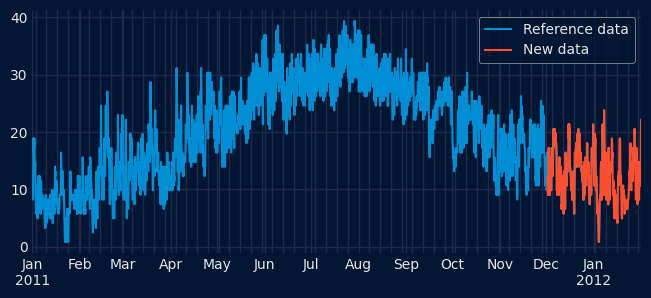

In [25]:
# Reference and new data plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
test_data_starts = '2011-12-01 22:00:00'
test_data_ends = '2012-01-31 23:00:00'
reference_data = data_train.loc[:, 'temp'].copy()
test_data = data.loc[test_data_starts:test_data_ends, 'temp'].copy()
reference_data.plot(ax=ax, label='Reference data')
test_data.plot(ax=ax, label='New data')
ax.set_xlabel("")
ax.legend()
plt.show();


A **Kolmogorov–Smirnov (KS) test** is used to compare the distributions of the training data and the new data. The **null hypothesis** states that both samples are drawn from the same underlying distribution. If the resulting *p-value* falls below a chosen significance level (commonly 0.05), the null hypothesis is rejected, indicating that the distributions differ significantly — a potential sign of **data drift**.

In [26]:
# Kolmogorov-Smirnov test to compare both data sets
# ==============================================================================
ks_2samp(
    reference_data,
    test_data,
)

KstestResult(statistic=np.float64(0.46407230559345153), pvalue=np.float64(1.909015241720514e-247), statistic_location=np.float64(18.86), statistic_sign=np.int8(-1))

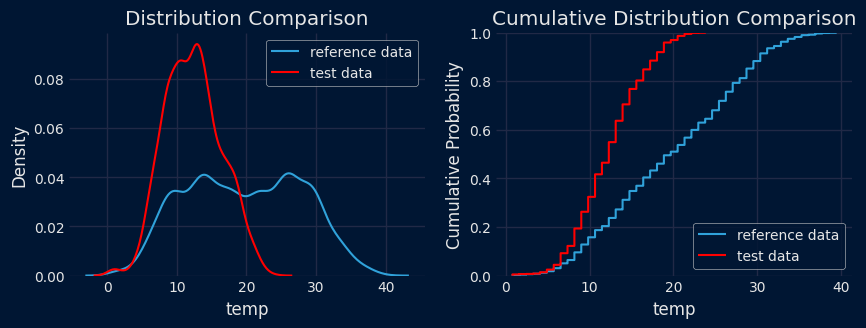

In [27]:
# Plots to compare both data sets
# ==============================================================================
fig, axs = plt.subplots(ncols=2, figsize=(9, 3))
sns.kdeplot(reference_data, label='reference data', color='#30a2da', ax=axs[0])
sns.kdeplot(test_data, label='test data', color='red', ax=axs[0])
axs[0].set_title('Distribution Comparison')
axs[0].set_ylabel('Density')
axs[0].legend()

sns.ecdfplot(reference_data, label='reference data', color='#30a2da', ax=axs[1])
sns.ecdfplot(test_data, label='test data', color='red', ax=axs[1])
axs[1].set_title('Cumulative Distribution Comparison')
axs[1].set_ylabel('Cumulative Probability')
axs[1].legend()
plt.show();

The statistical tests and visualizations shown above **indicate a clear difference** between the distributions, even though we know that no drift is actually present.
This highlights the importance of using **methods specifically designed for time series data**, since traditional statistical tests may yield misleading results due to the **temporal dependencies and recurring patterns** inherent in such data.

### Distance-based framework for temporal drift detection

This framework implements a distance-based, data-driven approach to detect temporal drift — changes in the underlying data distribution over time — within time series data. It constructs an empirical baseline of normal behavior from historical (reference) data and uses it to assess whether newly observed data deviates significantly from the established norm.

The approach is both model-agnostic and distance-agnostic: any statistical distance or divergence measure that quantifies dissimilarity between data samples can be employed (e.g., Kolmogorov–Smirnov, Chi-squared, Jensen–Shannon divergence, or other appropriate metrics).


#### 1. Reference Phase — Estimating the Empirical Distribution

The first step is to characterize the **natural variability** of the time series under stable conditions.

1. **Select a reference window**  
   Choose a historical segment of the time series that represents stable and drift-free behavior. This segment serves as the *reference dataset*.

2. **Segment the reference data**  
   Divide the reference time series into non-overlapping chunks of equal length:
   $$
   \{ C_1, C_2, \ldots, C_n \}
   $$  
   Each chunk $C_i$ corresponds to a fixed temporal window (e.g., one week, one month, or a fixed number of samples).

3. **Compute pairwise distances**  
   For each chunk $C_i$, compute its distance from the remainder of the reference dataset (or a representative aggregation thereof).  
   This produces a collection of distances:
   $$
   \mathbb{D}_{ref} = \{ d_1, d_2, \ldots, d_n \}
   $$

4. **Build the empirical distribution**  
   The set $\mathbb{D}_{ref}$ represents the distribution of distances under normal (non-drifting) conditions. It quantifies the typical level of dissimilarity between stable data segments.

5. **Define a drift threshold**  
   Select a quantile (e.g., the 95th percentile) from the empirical distribution $\mathbb{D}_{ref}$ as the drift threshold:
   $$
   \tau = Q_{0.95}(\mathbb{D}_{ref})
   $$  
   Any distance greater than $\tau$ indicates a deviation beyond what is expected under normal variability.


<p style="text-align: center">
    <img src="../img/population_drift_detection.gif" style="width: 750px;">
    <br>
    <font size="2.5"> <i>Population Drift Detection - Animation</i></font>
</p>

#### 2. Monitoring Phase — Detecting Drift in New Data

Once the baseline distribution is established, new data can be continuously evaluated for drift.

1. **Chunk new data**  
   As new observations become available, segment them into chunks of the same length used in the reference phase:
   $$
   \{ C'_1, C'_2, \ldots, C'_m \}
   $$

2. **Compute distances to the reference**  
   For each new chunk $C'_j$, compute its distance to the reference baseline (either to all reference chunks or to an aggregated representation of the reference distribution).

3. **Compare against the threshold**  
   - If $d(C'_j, \text{reference}) \leq \tau$, the data is consistent with the reference distribution.  
   - If $d(C'_j, \text{reference}) > \tau$, flag the chunk as exhibiting potential drift.

4. **Interpretation**  
   A flagged chunk suggests that the new data segment differs significantly from historical norms, implying a possible population drift or concept shift.  Such cases may warrant further investigation, model retraining, or data pipeline adjustments.
